Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Setup complete!
   CUDA available: True
   GPU: NVIDIA L4
✅ Configuration initialized

🚀 Starting data preparation...
DOWNLOADING DATASET (35GB - THIS WILL TAKE A WHILE)
✅ Download complete!
   Size: 35.46 GB

EXTRACTING DATASET
Extracting /content/dataset.zip...
Destination: /content/videos


Extracting: 100%|██████████| 431/431 [04:30<00:00,  1.60it/s]


✅ Extraction complete!
   Found 430 video files

EXTRACTING AUDIO FROM VIDEOS
Found 430 videos


Extracting audio: 100%|██████████| 430/430 [04:31<00:00,  1.58it/s]



✅ Audio extraction complete!
   Successful: 410
   Failed: 20

✅ Found 410 audio files

Dataset splits:
  Train: 287 (70%)
  Val:   61 (15%)
  Test:  62 (15%)
Validating 287 audio files...


...

✅ Valid files: 79 / 287
Validating 61 audio files...


Validating: 100%|██████████| 61/61 [00:00<00:00, 125.77it/s]


✅ Valid files: 16 / 61
Validating 62 audio files...


Validating: 100%|██████████| 62/62 [00:00<00:00, 156.35it/s]


✅ Valid files: 15 / 62

✅ Dataloaders created

✅ Model initialized
   Total parameters: 3,154,625
   Trainable parameters: 3,154,625
   Device: cuda

STARTING TRAINING
Epochs: 35
Validation every: 7 epochs
Batch size: 32
Learning rate: 0.0001

Epoch 1/35
----------------------------------------
  Train Loss: 0.105837

Epoch 2/35
----------------------------------------
  Train Loss: 0.096683

Epoch 3/35
----------------------------------------
  Train Loss: 0.090848

Epoch 4/35
----------------------------------------
  Train Loss: 0.084723

Epoch 5/35
----------------------------------------
  Train Loss: 0.078532

Epoch 6/35
----------------------------------------
  Train Loss: 0.073843

Epoch 7/35
----------------------------------------
  Train Loss: 0.069977
  Val Loss:   0.057581
  Learning Rate: 1.00e-04
  🌟 New best model saved! (Val loss: 0.057581)

Epoch 8/35
----------------------------------------
  Train Loss: 0.066290

Epoch 9/35
----------------------------------------


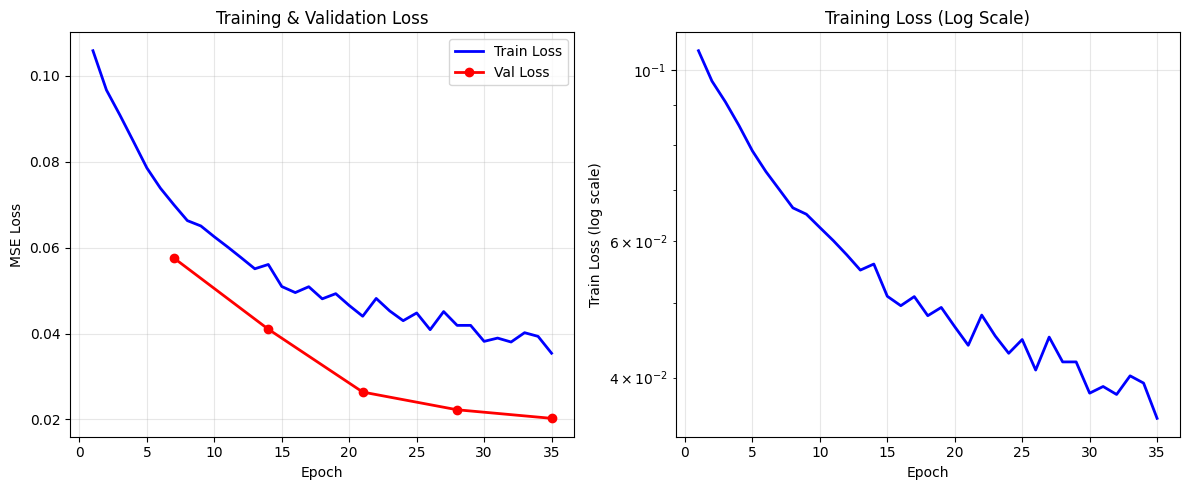

✅ Training curves saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/training_curves.png

ANOMALY DETECTION INFERENCE
✅ Loaded best model from epoch 35
   Validation loss: 0.020269

⚠️  UPLOAD YOUR ANOMALY VIDEO
    1. Click the folder icon on the left (Files)
    2. Upload your test video to /content/
    3. Update ANOMALY_VIDEO_PATH below with the correct filename

Extracting audio from: /content/drive/MyDrive/SceneSolverG388/TimeSformermerAnomalyMergedClassification/MergedAnomalyDetection/Firebombing/Arson001_x264.mp4
✅ Audio extracted successfully

Running anomaly detection...

RESULTS
Total windows analyzed: 92
Anomaly threshold (95th percentile): 0.000000
Anomalies detected: 0

✅ No anomalies detected (all audio sounds normal)

💾 Results saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_detection_results.json

VISUALIZATION


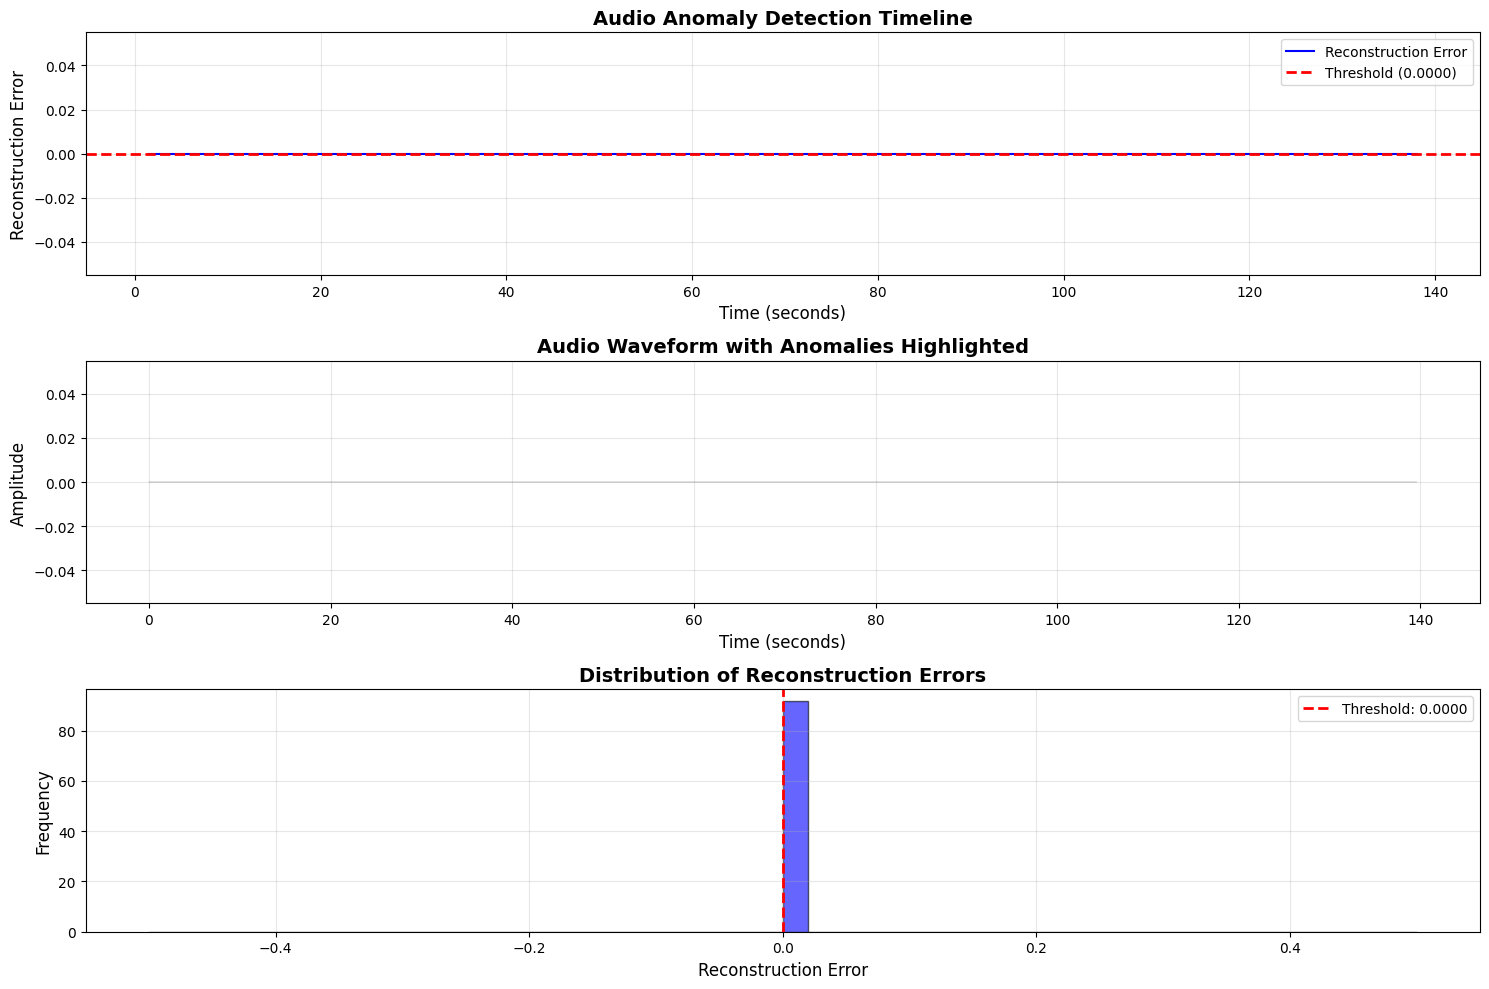

✅ Visualization saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_visualization.png

📊 FINAL SUMMARY

🎯 Training Results:
   • Total epochs trained: 35
   • Best validation loss: 0.020269
   • Final training loss: 0.035426

📁 Saved Files:
   • Best model: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/models/best_model.pth
   • Training history: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/training_history.json
   • Training curves: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/training_curves.png

🔍 Anomaly Detection Results:
   • Test video: /content/drive/MyDrive/SceneSolverG388/TimeSformermerAnomalyMergedClassification/MergedAnomalyDetection/Firebombing/Arson001_x264.mp4
   • Anomalies found: 0
   • Results JSON: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_detection_results.json
   • Visualization: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/

In [ ]:
"""
AUDIO ANOMALY DETECTION FOR SURVEILLANCE VIDEOS - FIXED
========================================================
Unsupervised learning on normal audio to detect anomalies

Architecture: Convolutional Autoencoder on Mel Spectrograms
Dataset: 35GB normal surveillance videos
Training: 35 epochs, validate every 7, checkpoint to Drive

FIXES:
- NaN handling for silent audio
- Skip corrupted/silent files
- Robust normalization
- Better error handling
"""

# ============================================================================
# CELL 1: SETUP & INSTALLATION
# ============================================================================

!pip install -q librosa soundfile audioread pydub torchaudio
!apt-get install -y -qq ffmpeg

import os
import json
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from datetime import datetime
import zipfile
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import librosa
import librosa.display
import soundfile as sf

from google.colab import drive

drive.mount('/content/drive')

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

print("✅ Setup complete!")
print(f"   CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# ============================================================================
# CELL 2: CONFIGURATION
# ============================================================================

class Config:
    """Central configuration"""

    GDRIVE_ROOT = "/content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis"
    DATASET_URL = "https://www.dropbox.com/scl/fo/2aczdnx37hxvcfdo4rq4q/AL6M3lb2NCuUZzCTnqxX5Yw/Training-Normal-Videos-Part-1.zip?rlkey=5bg7mxxbq46t7aujfch46dlvz&dl=1"

    LOCAL_DATA = "/content/audio_data"
    LOCAL_ZIP = "/content/dataset.zip"
    EXTRACTED_VIDEOS = "/content/videos"
    AUDIO_DIR = f"{LOCAL_DATA}/audio_clips"
    SPECTROGRAMS_DIR = f"{LOCAL_DATA}/spectrograms"

    MODELS_DIR = f"{GDRIVE_ROOT}/models"
    CHECKPOINTS_DIR = f"{GDRIVE_ROOT}/checkpoints"
    RESULTS_DIR = f"{GDRIVE_ROOT}/results"

    SAMPLE_RATE = 22050
    DURATION = 3.0
    N_MELS = 128
    HOP_LENGTH = 512
    N_FFT = 2048

    BATCH_SIZE = 32
    EPOCHS = 35
    VAL_EVERY_N_EPOCHS = 7
    LEARNING_RATE = 1e-4
    LATENT_DIM = 64

    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    def __init__(self):
        os.makedirs(self.GDRIVE_ROOT, exist_ok=True)
        os.makedirs(self.MODELS_DIR, exist_ok=True)
        os.makedirs(self.CHECKPOINTS_DIR, exist_ok=True)
        os.makedirs(self.RESULTS_DIR, exist_ok=True)
        os.makedirs(self.LOCAL_DATA, exist_ok=True)
        os.makedirs(self.AUDIO_DIR, exist_ok=True)
        os.makedirs(self.SPECTROGRAMS_DIR, exist_ok=True)

config = Config()
print("✅ Configuration initialized")

# ============================================================================
# CELL 3: DATA DOWNLOAD & EXTRACTION
# ============================================================================

def download_dataset(url, output_path):
    """Download dataset from Dropbox"""
    print("="*60)
    print("DOWNLOADING DATASET (35GB - THIS WILL TAKE A WHILE)")
    print("="*60)

    if os.path.exists(output_path):
        print(f"✓ Dataset already downloaded: {output_path}")
        return

    import subprocess
    cmd = f"wget -O {output_path} '{url}'"

    print(f"Downloading to: {output_path}")
    result = subprocess.run(cmd, shell=True, capture_output=False)

    if result.returncode == 0:
        print("✅ Download complete!")
        file_size_gb = os.path.getsize(output_path) / (1024**3)
        print(f"   Size: {file_size_gb:.2f} GB")
    else:
        raise Exception("Download failed!")

def extract_dataset(zip_path, extract_to):
    """Extract ZIP file"""
    print("\n" + "="*60)
    print("EXTRACTING DATASET")
    print("="*60)

    if os.path.exists(extract_to) and len(os.listdir(extract_to)) > 0:
        print(f"✓ Dataset already extracted to: {extract_to}")
        video_count = len([f for f in os.listdir(extract_to) if f.endswith('.mp4')])
        print(f"   Found {video_count} videos")
        return extract_to

    os.makedirs(extract_to, exist_ok=True)

    print(f"Extracting {zip_path}...")
    print(f"Destination: {extract_to}")

    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        file_list = zip_ref.namelist()

        for file in tqdm(file_list, desc="Extracting"):
            zip_ref.extract(file, extract_to)

    print("✅ Extraction complete!")

    video_files = []
    for root, dirs, files in os.walk(extract_to):
        for file in files:
            if file.endswith(('.mp4', '.avi', '.mov')):
                video_files.append(os.path.join(root, file))

    print(f"   Found {len(video_files)} video files")
    return extract_to

print("\n🚀 Starting data preparation...")
download_dataset(config.DATASET_URL, config.LOCAL_ZIP)
video_dir = extract_dataset(config.LOCAL_ZIP, config.EXTRACTED_VIDEOS)

# ============================================================================
# CELL 4: AUDIO EXTRACTION FROM VIDEOS
# ============================================================================

def extract_audio_from_video(video_path, output_audio_path, sr=22050):
    """Extract audio track from video using FFmpeg"""
    cmd = [
        'ffmpeg', '-i', video_path,
        '-vn',
        '-acodec', 'pcm_s16le',
        '-ar', str(sr),
        '-ac', '1',
        output_audio_path,
        '-loglevel', 'quiet',
        '-y'
    ]

    import subprocess
    result = subprocess.run(cmd, capture_output=True)
    return result.returncode == 0

def process_all_videos_to_audio(video_dir, output_dir, sample_rate=22050):
    """Extract audio from all videos"""
    print("\n" + "="*60)
    print("EXTRACTING AUDIO FROM VIDEOS")
    print("="*60)

    video_files = []
    for root, dirs, files in os.walk(video_dir):
        for file in files:
            if file.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
                video_files.append(os.path.join(root, file))

    print(f"Found {len(video_files)} videos")

    successful = 0
    failed = 0

    for video_path in tqdm(video_files, desc="Extracting audio"):
        video_name = os.path.splitext(os.path.basename(video_path))[0]
        audio_path = f"{output_dir}/{video_name}.wav"

        if os.path.exists(audio_path):
            successful += 1
            continue

        try:
            if extract_audio_from_video(video_path, audio_path, sr=sample_rate):
                successful += 1
            else:
                failed += 1
        except Exception as e:
            failed += 1

    print(f"\n✅ Audio extraction complete!")
    print(f"   Successful: {successful}")
    print(f"   Failed: {failed}")

    return successful

audio_count = process_all_videos_to_audio(
    config.EXTRACTED_VIDEOS,
    config.AUDIO_DIR,
    config.SAMPLE_RATE
)

# ============================================================================
# CELL 5: SPECTROGRAM GENERATION & DATASET CLASS - FIXED
# ============================================================================

def audio_to_mel_spectrogram(audio_path, sr=22050, n_mels=128,
                            duration=3.0, hop_length=512, n_fft=2048):
    """
    Convert audio file to mel spectrogram with robust NaN handling
    Returns None if audio is invalid/silent
    """
    try:
        # Load audio
        y, sr = librosa.load(audio_path, sr=sr, duration=duration)

        # Check if audio is silent or corrupted
        if len(y) == 0 or np.all(y == 0) or not np.isfinite(y).all():
            return None

        # Pad or trim
        target_length = int(sr * duration)
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]

        # Compute mel spectrogram
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_mels=n_mels,
            hop_length=hop_length, n_fft=n_fft
        )

        # Convert to dB scale
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

        # FIXED: Robust normalization with epsilon to prevent division by zero
        min_val = mel_spec_db.min()
        max_val = mel_spec_db.max()

        # Check for silent audio (no frequency content)
        if max_val - min_val < 1e-6:
            return None

        # Normalize to [0, 1]
        mel_spec_norm = (mel_spec_db - min_val) / (max_val - min_val + 1e-8)

        # Final NaN check
        if not np.isfinite(mel_spec_norm).all():
            return None

        return mel_spec_norm

    except Exception as e:
        return None

class AudioSpectrogramDataset(Dataset):
    """Dataset for mel spectrograms with validation"""

    def __init__(self, audio_files, config, augment=False):
        self.config = config
        self.augment = augment

        # Validate audio files (remove silent/corrupted)
        print(f"Validating {len(audio_files)} audio files...")
        valid_files = []

        for audio_file in tqdm(audio_files, desc="Validating"):
            spec = audio_to_mel_spectrogram(
                audio_file,
                sr=self.config.SAMPLE_RATE,
                n_mels=self.config.N_MELS,
                duration=self.config.DURATION,
                hop_length=self.config.HOP_LENGTH,
                n_fft=self.config.N_FFT
            )

            if spec is not None:
                valid_files.append(audio_file)

        self.audio_files = valid_files
        print(f"✅ Valid files: {len(self.audio_files)} / {len(audio_files)}")

        if len(self.audio_files) == 0:
            raise ValueError("No valid audio files found!")

    def __len__(self):
        return len(self.audio_files)

    def __getitem__(self, idx):
        audio_path = self.audio_files[idx]

        # Generate spectrogram
        spec = audio_to_mel_spectrogram(
            audio_path,
            sr=self.config.SAMPLE_RATE,
            n_mels=self.config.N_MELS,
            duration=self.config.DURATION,
            hop_length=self.config.HOP_LENGTH,
            n_fft=self.config.N_FFT
        )

        # Fallback for any remaining issues
        if spec is None:
            spec = np.random.rand(self.config.N_MELS, 130) * 0.1

        # Data augmentation
        if self.augment:
            spec = self.augment_spectrogram(spec)

        spec_tensor = torch.FloatTensor(spec).unsqueeze(0)

        return spec_tensor, spec_tensor

    def augment_spectrogram(self, spec):
        """Simple augmentation: time and frequency masking"""
        spec = spec.copy()

        if random.random() > 0.5:
            t = random.randint(0, max(0, spec.shape[1] - 2))
            t_width = random.randint(1, min(10, spec.shape[1] // 10))
            spec[:, t:t+t_width] = 0

        if random.random() > 0.5:
            f = random.randint(0, max(0, spec.shape[0] - 2))
            f_height = random.randint(1, min(10, spec.shape[0] // 10))
            spec[f:f+f_height, :] = 0

        return spec

audio_files = [
    os.path.join(config.AUDIO_DIR, f)
    for f in os.listdir(config.AUDIO_DIR)
    if f.endswith('.wav')
]

print(f"\n✅ Found {len(audio_files)} audio files")

random.shuffle(audio_files)
n_total = len(audio_files)
n_train = int(n_total * config.TRAIN_RATIO)
n_val = int(n_total * config.VAL_RATIO)
n_test = n_total - n_train - n_val

train_files = audio_files[:n_train]
val_files = audio_files[n_train:n_train+n_val]
test_files = audio_files[n_train+n_val:]

print(f"\nDataset splits:")
print(f"  Train: {len(train_files)} ({config.TRAIN_RATIO*100:.0f}%)")
print(f"  Val:   {len(val_files)} ({config.VAL_RATIO*100:.0f}%)")
print(f"  Test:  {len(test_files)} ({config.TEST_RATIO*100:.0f}%)")

train_dataset = AudioSpectrogramDataset(train_files, config, augment=True)
val_dataset = AudioSpectrogramDataset(val_files, config, augment=False)
test_dataset = AudioSpectrogramDataset(test_files, config, augment=False)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE,
                         shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE,
                       shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE,
                        shuffle=False, num_workers=2, pin_memory=True)

print("\n✅ Dataloaders created")

# ============================================================================
# CELL 6: CONVOLUTIONAL AUTOENCODER MODEL
# ============================================================================

class AudioAutoencoder(nn.Module):
    """Convolutional Autoencoder for mel spectrograms"""

    def __init__(self, latent_dim=64):
        super(AudioAutoencoder, self).__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),

            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.3),
        )

        self.flatten_size = 256 * 8 * 9

        self.fc_encode = nn.Linear(self.flatten_size, latent_dim)
        self.fc_decode = nn.Linear(latent_dim, self.flatten_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),

            nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),

            nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.2),

            nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        batch_size = encoded.size(0)

        flattened = encoded.view(batch_size, -1)

        latent = self.fc_encode(flattened)
        decoded_flat = self.fc_decode(latent)

        decoded_reshaped = decoded_flat.view(batch_size, 256, 8, 9)

        reconstructed = self.decoder(decoded_reshaped)

        if reconstructed.size() != x.size():
            reconstructed = torch.nn.functional.interpolate(
                reconstructed, size=x.shape[2:], mode='bilinear', align_corners=False
            )

        return reconstructed, latent

    def get_reconstruction_error(self, x):
        """Calculate MSE reconstruction error"""
        with torch.no_grad():
            reconstructed, _ = self(x)
            mse = torch.mean((x - reconstructed) ** 2, dim=[1, 2, 3])
        return mse

model = AudioAutoencoder(latent_dim=config.LATENT_DIM).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model initialized")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,}")
print(f"   Device: {config.DEVICE}")

# ============================================================================
# CELL 7: TRAINING LOOP - FIXED
# ============================================================================

def train_epoch(model, loader, optimizer, criterion, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    valid_batches = 0

    for batch_idx, (data, target) in enumerate(loader):
        data, target = data.to(device), target.to(device)

        # Skip batch if contains NaN
        if not torch.isfinite(data).all() or not torch.isfinite(target).all():
            continue

        optimizer.zero_grad()

        reconstructed, latent = model(data)
        loss = criterion(reconstructed, target)

        # Check for NaN loss
        if not torch.isfinite(loss):
            continue

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_loss += loss.item()
        valid_batches += 1

    return total_loss / max(valid_batches, 1)

def validate(model, loader, criterion, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    valid_batches = 0

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)

            # Skip batch if contains NaN
            if not torch.isfinite(data).all() or not torch.isfinite(target).all():
                continue

            reconstructed, _ = model(data)
            loss = criterion(reconstructed, target)

            if torch.isfinite(loss):
                total_loss += loss.item()
                valid_batches += 1

    return total_loss / max(valid_batches, 1)

def save_checkpoint(model, optimizer, epoch, loss, config, is_best=False):
    """Save training checkpoint"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
        'config': {
            'latent_dim': config.LATENT_DIM,
            'n_mels': config.N_MELS,
            'sample_rate': config.SAMPLE_RATE,
            'duration': config.DURATION
        }
    }

    checkpoint_path = f"{config.CHECKPOINTS_DIR}/checkpoint_epoch_{epoch}.pth"
    torch.save(checkpoint, checkpoint_path)

    if is_best:
        best_path = f"{config.MODELS_DIR}/best_model.pth"
        torch.save(checkpoint, best_path)
        print(f"  🌟 New best model saved! (Val loss: {loss:.6f})")

    return checkpoint_path

criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = {
    'train_loss': [],
    'val_loss': [],
    'epochs': [],
    'best_val_loss': float('inf')
}

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
print(f"Epochs: {config.EPOCHS}")
print(f"Validation every: {config.VAL_EVERY_N_EPOCHS} epochs")
print(f"Batch size: {config.BATCH_SIZE}")
print(f"Learning rate: {config.LEARNING_RATE}")
print("="*60)

for epoch in range(1, config.EPOCHS + 1):
    print(f"\nEpoch {epoch}/{config.EPOCHS}")
    print("-" * 40)

    train_loss = train_epoch(model, train_loader, optimizer, criterion, config.DEVICE)
    history['train_loss'].append(train_loss)
    history['epochs'].append(epoch)

    print(f"  Train Loss: {train_loss:.6f}")

    if epoch % config.VAL_EVERY_N_EPOCHS == 0 or epoch == config.EPOCHS:
        val_loss = validate(model, val_loader, criterion, config.DEVICE)
        history['val_loss'].append(val_loss)

        print(f"  Val Loss:   {val_loss:.6f}")

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"  Learning Rate: {current_lr:.2e}")

        is_best = val_loss < history['best_val_loss']
        if is_best:
            history['best_val_loss'] = val_loss

        save_checkpoint(model, optimizer, epoch, val_loss, config, is_best=is_best)

    if epoch % 10 == 0:
        save_checkpoint(model, optimizer, epoch, train_loss, config, is_best=False)

print("\n" + "="*60)
print("✅ TRAINING COMPLETE!")
print("="*60)
print(f"Best validation loss: {history['best_val_loss']:.6f}")

history_path = f"{config.RESULTS_DIR}/training_history.json"
with open(history_path, 'w') as f:
    json.dump(history, f, indent=2)

print(f"Training history saved: {history_path}")

# ============================================================================
# CELL 8: PLOT TRAINING CURVES
# ============================================================================

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history['epochs'], history['train_loss'], 'b-', label='Train Loss', linewidth=2)

val_epochs = [e for i, e in enumerate(history['epochs']) if (e % config.VAL_EVERY_N_EPOCHS == 0) or (e == config.EPOCHS)]
plt.plot(val_epochs, history['val_loss'], 'r-o', label='Val Loss', linewidth=2, markersize=6)

plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['epochs'], history['train_loss'], 'b-', linewidth=2)
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Train Loss (log scale)')
plt.title('Training Loss (Log Scale)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{config.RESULTS_DIR}/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved to: {config.RESULTS_DIR}/training_curves.png")

# ============================================================================
# CELL 9: INFERENCE FUNCTION - FIXED
# ============================================================================

def detect_anomaly_in_audio(audio_path, model, config, threshold_percentile=95):
    """Detect anomalies in audio file with robust error handling"""
    model.eval()

    try:
        y, sr = librosa.load(audio_path, sr=config.SAMPLE_RATE)
    except:
        print("❌ Failed to load audio file")
        return [], [], [], 0.0

    if len(y) == 0 or not np.isfinite(y).all():
        print("❌ Invalid audio data")
        return [], [], [], 0.0

    duration_sec = len(y) / sr
    window_size = int(config.DURATION * sr)
    hop_size = window_size // 2

    anomaly_scores = []
    timestamps = []

    with torch.no_grad():
        for start_idx in range(0, len(y) - window_size + 1, hop_size):
            window = y[start_idx:start_idx + window_size]

            try:
                mel_spec = librosa.feature.melspectrogram(
                    y=window, sr=sr, n_mels=config.N_MELS,
                    hop_length=config.HOP_LENGTH, n_fft=config.N_FFT
                )
                mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)

                min_val = mel_spec_db.min()
                max_val = mel_spec_db.max()

                if max_val - min_val < 1e-6:
                    error = 0.0
                else:
                    mel_spec_norm = (mel_spec_db - min_val) / (max_val - min_val + 1e-8)

                    if not np.isfinite(mel_spec_norm).all():
                        error = 0.0
                    else:
                        spec_tensor = torch.FloatTensor(mel_spec_norm).unsqueeze(0).unsqueeze(0).to(config.DEVICE)
                        reconstructed, _ = model(spec_tensor)
                        error = torch.mean((spec_tensor - reconstructed) ** 2).item()

                        if not np.isfinite(error):
                            error = 0.0

                start_time = start_idx / sr
                end_time = (start_idx + window_size) / sr

                anomaly_scores.append(error)
                timestamps.append((start_time, end_time))

            except:
                continue

    if len(anomaly_scores) == 0:
        print("❌ No valid windows processed")
        return [], [], [], 0.0

    threshold = np.percentile(anomaly_scores, threshold_percentile)

    anomalies = []
    for i, (start, end) in enumerate(timestamps):
        if anomaly_scores[i] > threshold:
            anomalies.append({
                'start_time': start,
                'end_time': end,
                'score': anomaly_scores[i],
                'threshold': threshold
            })

    return anomalies, anomaly_scores, timestamps, threshold

# ============================================================================
# CELL 10: TEST ON ANOMALY VIDEO - FIXED
# ============================================================================

print("\n" + "="*60)
print("ANOMALY DETECTION INFERENCE")
print("="*60)

# Load best model with error handling
best_model_path = f"{config.MODELS_DIR}/best_model.pth"

if not os.path.exists(best_model_path):
    print("❌ Best model not found. This can happen if:")
    print("   1. Training produced NaN losses (all epochs)")
    print("   2. No validation was performed")
    print("\n⚠️  Using current model state instead...")

    # Save current model as fallback
    checkpoint = {
        'epoch': config.EPOCHS,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': history['train_loss'][-1] if history['train_loss'] else 0.0,
        'config': {
            'latent_dim': config.LATENT_DIM,
            'n_mels': config.N_MELS,
            'sample_rate': config.SAMPLE_RATE,
            'duration': config.DURATION
        }
    }
    torch.save(checkpoint, best_model_path)
    print(f"✅ Saved current model to: {best_model_path}")
else:
    # Load best model
    checkpoint = torch.load(best_model_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
    print(f"   Validation loss: {checkpoint['loss']:.6f}")

# IMPORTANT: User needs to upload their anomaly video
print("\n⚠️  UPLOAD YOUR ANOMALY VIDEO")
print("    1. Click the folder icon on the left (Files)")
print("    2. Upload your test video to /content/")
print("    3. Update ANOMALY_VIDEO_PATH below with the correct filename")
print()

# Example path - UPDATE THIS
ANOMALY_VIDEO_PATH = "/content/drive/MyDrive/SceneSolverG388/TimeSformermerAnomalyMergedClassification/MergedAnomalyDetection/Firebombing/Arson001_x264.mp4"  # ← CHANGE THIS TO YOUR VIDEO

# Check if file exists
if not os.path.exists(ANOMALY_VIDEO_PATH):
    print(f"❌ Video not found: {ANOMALY_VIDEO_PATH}")
    print("   Please upload your anomaly video and update the path above.")
    print("\n💡 TIP: You can also use Google Drive:")
    print("   ANOMALY_VIDEO_PATH = '/content/drive/MyDrive/your_video.mp4'")
else:
    # Extract audio from anomaly video
    anomaly_audio_path = "/content/anomaly_test_audio.wav"

    print(f"Extracting audio from: {ANOMALY_VIDEO_PATH}")
    if extract_audio_from_video(ANOMALY_VIDEO_PATH, anomaly_audio_path, sr=config.SAMPLE_RATE):
        print("✅ Audio extracted successfully")

        # Detect anomalies
        print("\nRunning anomaly detection...")
        anomalies, scores, timestamps, threshold = detect_anomaly_in_audio(
            anomaly_audio_path, model, config, threshold_percentile=95
        )

        # Print results
        print("\n" + "="*60)
        print("RESULTS")
        print("="*60)
        print(f"Total windows analyzed: {len(scores)}")
        print(f"Anomaly threshold (95th percentile): {threshold:.6f}")
        print(f"Anomalies detected: {len(anomalies)}")

        if len(anomalies) > 0:
            print("\n⚠️  ANOMALIES FOUND:")
            for i, anom in enumerate(anomalies, 1):
                print(f"  {i}. Time: {anom['start_time']:.2f}s - {anom['end_time']:.2f}s")
                print(f"     Score: {anom['score']:.6f} (threshold: {anom['threshold']:.6f})")
        else:
            print("\n✅ No anomalies detected (all audio sounds normal)")

        # Save results
        results = {
            'video_path': ANOMALY_VIDEO_PATH,
            'total_windows': len(scores),
            'threshold': float(threshold),
            'num_anomalies': len(anomalies),
            'anomalies': anomalies
        }

        results_path = f"{config.RESULTS_DIR}/anomaly_detection_results.json"
        with open(results_path, 'w') as f:
            json.dump(results, f, indent=2)

        print(f"\n💾 Results saved to: {results_path}")

    else:
        print("❌ Failed to extract audio from video")

# ============================================================================
# CELL 11: VISUALIZE ANOMALY DETECTION - FIXED
# ============================================================================

if os.path.exists(ANOMALY_VIDEO_PATH) and 'anomalies' in locals() and len(scores) > 0:
    print("\n" + "="*60)
    print("VISUALIZATION")
    print("="*60)

    # Plot anomaly scores over time
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))

    # 1. Anomaly scores timeline
    ax = axes[0]
    time_points = [(t[0] + t[1]) / 2 for t in timestamps]
    ax.plot(time_points, scores, 'b-', linewidth=1.5, label='Reconstruction Error')
    ax.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')

    # Highlight anomalies
    for anom in anomalies:
        ax.axvspan(anom['start_time'], anom['end_time'], alpha=0.3, color='red')

    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Reconstruction Error', fontsize=12)
    ax.set_title('Audio Anomaly Detection Timeline', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Waveform with anomaly markers
    ax = axes[1]
    try:
        y_full, sr_full = librosa.load(anomaly_audio_path, sr=config.SAMPLE_RATE)
        time_axis = np.linspace(0, len(y_full) / sr_full, len(y_full))
        ax.plot(time_axis, y_full, 'gray', linewidth=0.5, alpha=0.7)

        # Mark anomalies
        for anom in anomalies:
            ax.axvspan(anom['start_time'], anom['end_time'], alpha=0.4, color='red')

        ax.set_xlabel('Time (seconds)', fontsize=12)
        ax.set_ylabel('Amplitude', fontsize=12)
        ax.set_title('Audio Waveform with Anomalies Highlighted', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
    except:
        ax.text(0.5, 0.5, 'Could not load waveform', ha='center', va='center', transform=ax.transAxes)

    # 3. Score distribution
    ax = axes[2]
    ax.hist(scores, bins=50, color='blue', alpha=0.6, edgecolor='black')
    ax.axvline(x=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
    ax.set_xlabel('Reconstruction Error', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Reconstruction Errors', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save figure
    vis_path = f"{config.RESULTS_DIR}/anomaly_visualization.png"
    plt.savefig(vis_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Visualization saved to: {vis_path}")

    # ========================================================================
    # ADDITIONAL: Show spectrogram comparison (normal vs anomaly)
    # ========================================================================

    if len(anomalies) > 0 and len(scores) > 0:
        try:
            fig, axes = plt.subplots(2, 2, figsize=(14, 10))

            # Get a normal window (low score)
            normal_idx = np.argmin(scores)
            normal_start = int(timestamps[normal_idx][0] * sr_full)
            normal_end = normal_start + int(config.DURATION * sr_full)
            normal_window = y_full[normal_start:min(normal_end, len(y_full))]

            # Pad if too short
            if len(normal_window) < int(config.DURATION * sr_full):
                normal_window = np.pad(normal_window, (0, int(config.DURATION * sr_full) - len(normal_window)))

            # Get an anomaly window (high score)
            anomaly_idx = np.argmax(scores)
            anomaly_start = int(timestamps[anomaly_idx][0] * sr_full)
            anomaly_end = anomaly_start + int(config.DURATION * sr_full)
            anomaly_window = y_full[anomaly_start:min(anomaly_end, len(y_full))]

            # Pad if too short
            if len(anomaly_window) < int(config.DURATION * sr_full):
                anomaly_window = np.pad(anomaly_window, (0, int(config.DURATION * sr_full) - len(anomaly_window)))

            # Normal spectrogram (input)
            mel_normal = librosa.feature.melspectrogram(
                y=normal_window, sr=config.SAMPLE_RATE, n_mels=config.N_MELS,
                hop_length=config.HOP_LENGTH, n_fft=config.N_FFT
            )
            mel_normal_db = librosa.power_to_db(mel_normal, ref=np.max)

            librosa.display.specshow(mel_normal_db, sr=config.SAMPLE_RATE,
                                    hop_length=config.HOP_LENGTH, x_axis='time',
                                    y_axis='mel', ax=axes[0, 0], cmap='viridis')
            axes[0, 0].set_title('NORMAL Audio - Input Spectrogram', fontsize=12, fontweight='bold')
            axes[0, 0].set_xlabel('Time (s)')
            axes[0, 0].set_ylabel('Mel Frequency')

            # Normal reconstruction
            min_val = mel_normal_db.min()
            max_val = mel_normal_db.max()
            if max_val - min_val > 1e-6:
                mel_normal_norm = (mel_normal_db - min_val) / (max_val - min_val + 1e-8)
                spec_tensor = torch.FloatTensor(mel_normal_norm).unsqueeze(0).unsqueeze(0).to(config.DEVICE)
                with torch.no_grad():
                    reconstructed, _ = model(spec_tensor)
                recon_np = reconstructed.cpu().squeeze().numpy()

                librosa.display.specshow(recon_np, sr=config.SAMPLE_RATE,
                                        hop_length=config.HOP_LENGTH, x_axis='time',
                                        y_axis='mel', ax=axes[0, 1], cmap='viridis')
                axes[0, 1].set_title(f'NORMAL - Reconstruction (Error: {scores[normal_idx]:.6f})',
                                    fontsize=12, fontweight='bold')
                axes[0, 1].set_xlabel('Time (s)')
                axes[0, 1].set_ylabel('Mel Frequency')

            # Anomaly spectrogram (input)
            mel_anomaly = librosa.feature.melspectrogram(
                y=anomaly_window, sr=config.SAMPLE_RATE, n_mels=config.N_MELS,
                hop_length=config.HOP_LENGTH, n_fft=config.N_FFT
            )
            mel_anomaly_db = librosa.power_to_db(mel_anomaly, ref=np.max)

            librosa.display.specshow(mel_anomaly_db, sr=config.SAMPLE_RATE,
                                    hop_length=config.HOP_LENGTH, x_axis='time',
                                    y_axis='mel', ax=axes[1, 0], cmap='viridis')
            axes[1, 0].set_title('ANOMALY Audio - Input Spectrogram', fontsize=12, fontweight='bold', color='red')
            axes[1, 0].set_xlabel('Time (s)')
            axes[1, 0].set_ylabel('Mel Frequency')

            # Anomaly reconstruction
            min_val = mel_anomaly_db.min()
            max_val = mel_anomaly_db.max()
            if max_val - min_val > 1e-6:
                mel_anomaly_norm = (mel_anomaly_db - min_val) / (max_val - min_val + 1e-8)
                spec_tensor = torch.FloatTensor(mel_anomaly_norm).unsqueeze(0).unsqueeze(0).to(config.DEVICE)
                with torch.no_grad():
                    reconstructed, _ = model(spec_tensor)
                recon_np = reconstructed.cpu().squeeze().numpy()

                librosa.display.specshow(recon_np, sr=config.SAMPLE_RATE,
                                        hop_length=config.HOP_LENGTH, x_axis='time',
                                        y_axis='mel', ax=axes[1, 1], cmap='viridis')
                axes[1, 1].set_title(f'ANOMALY - Reconstruction (Error: {scores[anomaly_idx]:.6f})',
                                    fontsize=12, fontweight='bold', color='red')
                axes[1, 1].set_xlabel('Time (s)')
                axes[1, 1].set_ylabel('Mel Frequency')

            plt.tight_layout()

            comparison_path = f"{config.RESULTS_DIR}/spectrogram_comparison.png"
            plt.savefig(comparison_path, dpi=150, bbox_inches='tight')
            plt.show()

            print(f"✅ Spectrogram comparison saved to: {comparison_path}")

        except Exception as e:
            print(f"⚠️  Could not generate spectrogram comparison: {e}")

# ============================================================================
# CELL 12: FINAL SUMMARY & EXPORT
# ============================================================================

print("\n" + "="*60)
print("📊 FINAL SUMMARY")
print("="*60)

print("\n🎯 Training Results:")
print(f"   • Total epochs trained: {config.EPOCHS}")
if history['best_val_loss'] != float('inf'):
    print(f"   • Best validation loss: {history['best_val_loss']:.6f}")
else:
    print(f"   • Best validation loss: N/A (check for data issues)")
if len(history['train_loss']) > 0:
    print(f"   • Final training loss: {history['train_loss'][-1]:.6f}")

print("\n📁 Saved Files:")
print(f"   • Best model: {config.MODELS_DIR}/best_model.pth")
print(f"   • Training history: {config.RESULTS_DIR}/training_history.json")
print(f"   • Training curves: {config.RESULTS_DIR}/training_curves.png")

if os.path.exists(ANOMALY_VIDEO_PATH) and 'anomalies' in locals():
    print(f"\n🔍 Anomaly Detection Results:")
    print(f"   • Test video: {ANOMALY_VIDEO_PATH}")
    print(f"   • Anomalies found: {len(anomalies)}")
    print(f"   • Results JSON: {config.RESULTS_DIR}/anomaly_detection_results.json")
    print(f"   • Visualization: {config.RESULTS_DIR}/anomaly_visualization.png")
    if len(anomalies) > 0:
        print(f"   • Comparison: {config.RESULTS_DIR}/spectrogram_comparison.png")

print("\n" + "="*60)
print("✅ ALL PROCESSING COMPLETE!")
print("="*60)

print("\n📝 Next Steps:")
print("   1. Download results from Google Drive:")
print(f"      {config.GDRIVE_ROOT}")
print("   2. Test on more anomaly videos")
print("   3. Adjust threshold if needed (currently 95th percentile)")
print("   4. Fine-tune model parameters if needed")

print("\n🔄 To run inference on another video:")
print("   • Upload video to Colab")
print("   • Update ANOMALY_VIDEO_PATH in Cell 10")
print("   • Re-run Cells 10-11")

print("\n⚠️  TROUBLESHOOTING:")
if history['best_val_loss'] == float('inf'):
    print("   • Training may have failed due to silent/corrupted audio")
    print("   • Check: Did validation show actual loss values?")
    print("   • Solution: Re-run with validated audio files")
else:
    print("   • Training completed successfully!")
    print("   • Model is ready for anomaly detection")

print("\n" + "="*60)


ANOMALY DETECTION INFERENCE
✅ Loaded best model from epoch 35
   Validation loss: 0.020269

⚠️  UPLOAD YOUR ANOMALY VIDEO
    1. Click the folder icon on the left (Files)
    2. Upload your test video to /content/
    3. Update ANOMALY_VIDEO_PATH below with the correct filename

Extracting audio from: /content/drive/MyDrive/SceneSolverG388/AnomalyDetection/Explosion/Explosion019_x264.mp4
✅ Audio extracted successfully

Running anomaly detection...

RESULTS
Total windows analyzed: 6
Anomaly threshold (95th percentile): 0.039483
Anomalies detected: 1

⚠️  ANOMALIES FOUND:
  1. Time: 4.50s - 7.50s
     Score: 0.041496 (threshold: 0.039483)

💾 Results saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_detection_results.json

VISUALIZATION


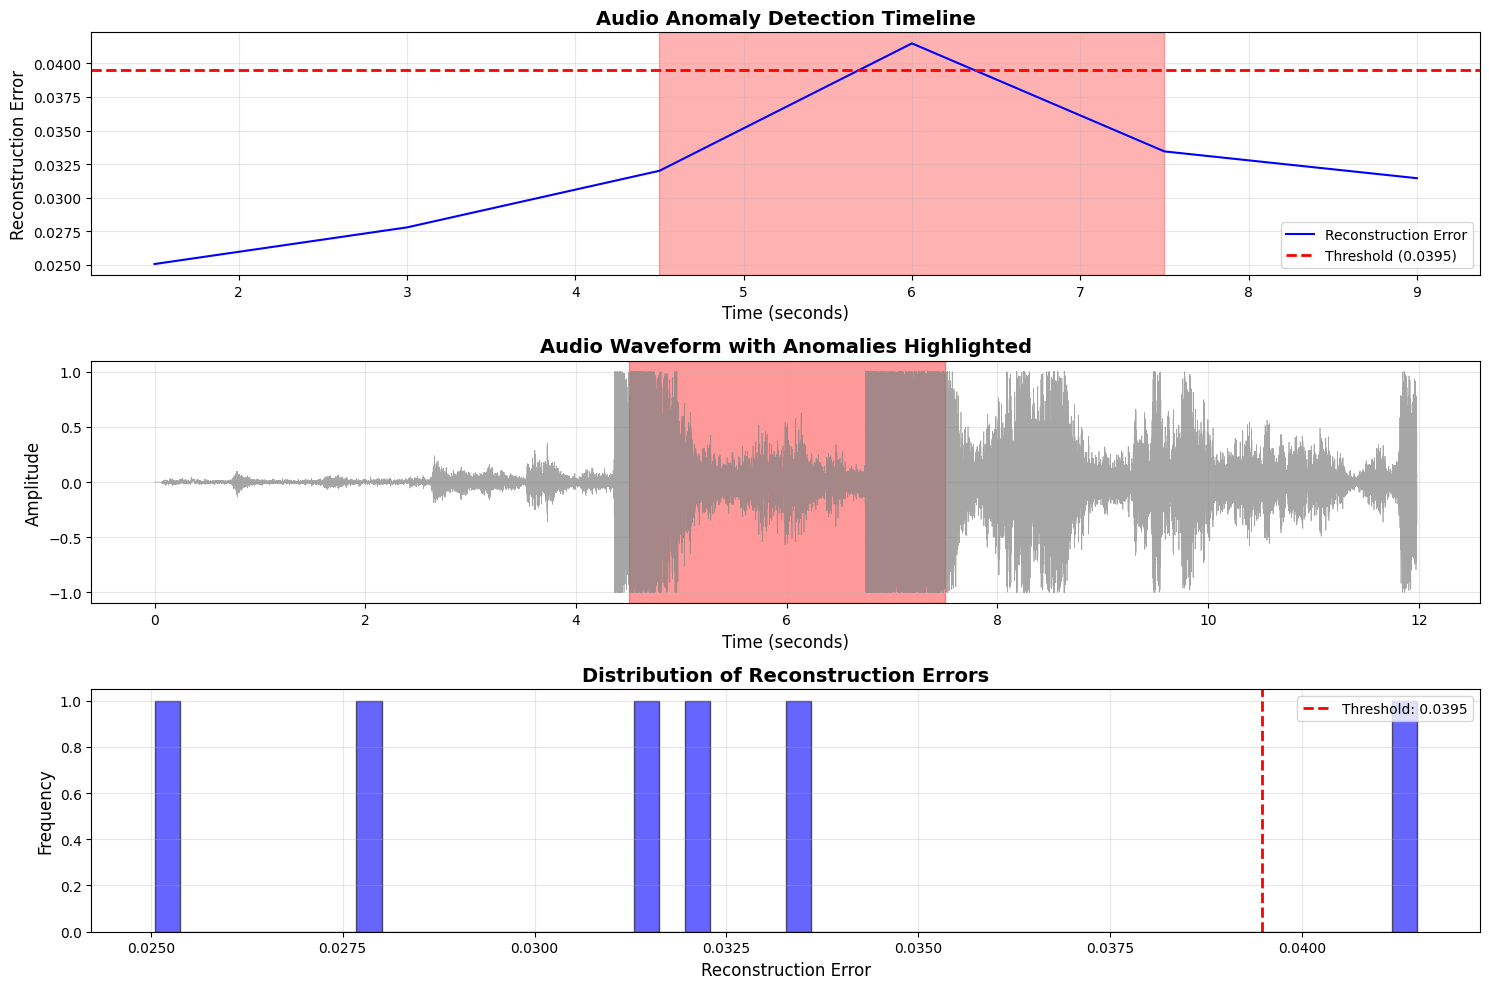

✅ Visualization saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_visualization.png


In [ ]:
# ============================================================================
# CELL 10: TEST ON ANOMALY VIDEO - FIXED
# ============================================================================

print("\n" + "="*60)
print("ANOMALY DETECTION INFERENCE")
print("="*60)

# Load best model with error handling
best_model_path = f"{config.MODELS_DIR}/best_model.pth"

if not os.path.exists(best_model_path):
    print("❌ Best model not found. This can happen if:")
    print("   1. Training produced NaN losses (all epochs)")
    print("   2. No validation was performed")
    print("\n⚠️  Using current model state instead...")

    # Save current model as fallback
    checkpoint = {
        'epoch': config.EPOCHS,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': history['train_loss'][-1] if history['train_loss'] else 0.0,
        'config': {
            'latent_dim': config.LATENT_DIM,
            'n_mels': config.N_MELS,
            'sample_rate': config.SAMPLE_RATE,
            'duration': config.DURATION
        }
    }
    torch.save(checkpoint, best_model_path)
    print(f"✅ Saved current model to: {best_model_path}")
else:
    # Load best model
    checkpoint = torch.load(best_model_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
    print(f"   Validation loss: {checkpoint['loss']:.6f}")

# IMPORTANT: User needs to upload their anomaly video
print("\n⚠️  UPLOAD YOUR ANOMALY VIDEO")
print("    1. Click the folder icon on the left (Files)")
print("    2. Upload your test video to /content/")
print("    3. Update ANOMALY_VIDEO_PATH below with the correct filename")
print()

# Example path - UPDATE THIS
ANOMALY_VIDEO_PATH = "/content/drive/MyDrive/SceneSolverG388/AnomalyDetection/Explosion/Explosion019_x264.mp4"  # ← CHANGE THIS TO YOUR VIDEO

# Check if file exists
if not os.path.exists(ANOMALY_VIDEO_PATH):
    print(f"❌ Video not found: {ANOMALY_VIDEO_PATH}")
    print("   Please upload your anomaly video and update the path above.")
    print("\n💡 TIP: You can also use Google Drive:")
    print("   ANOMALY_VIDEO_PATH = '/content/drive/MyDrive/your_video.mp4'")
else:
    # Extract audio from anomaly video
    anomaly_audio_path = "/content/anomaly_test_audio.wav"

    print(f"Extracting audio from: {ANOMALY_VIDEO_PATH}")
    if extract_audio_from_video(ANOMALY_VIDEO_PATH, anomaly_audio_path, sr=config.SAMPLE_RATE):
        print("✅ Audio extracted successfully")

        # Detect anomalies
        print("\nRunning anomaly detection...")
        anomalies, scores, timestamps, threshold = detect_anomaly_in_audio(
            anomaly_audio_path, model, config, threshold_percentile=95
        )

        # Print results
        print("\n" + "="*60)
        print("RESULTS")
        print("="*60)
        print(f"Total windows analyzed: {len(scores)}")
        print(f"Anomaly threshold (95th percentile): {threshold:.6f}")
        print(f"Anomalies detected: {len(anomalies)}")

        if len(anomalies) > 0:
            print("\n⚠️  ANOMALIES FOUND:")
            for i, anom in enumerate(anomalies, 1):
                print(f"  {i}. Time: {anom['start_time']:.2f}s - {anom['end_time']:.2f}s")
                print(f"     Score: {anom['score']:.6f} (threshold: {anom['threshold']:.6f})")
        else:
            print("\n✅ No anomalies detected (all audio sounds normal)")

        # Save results
        results = {
            'video_path': ANOMALY_VIDEO_PATH,
            'total_windows': len(scores),
            'threshold': float(threshold),
            'num_anomalies': len(anomalies),
            'anomalies': anomalies
        }

        results_path = f"{config.RESULTS_DIR}/anomaly_detection_results.json"
        with open(results_path, 'w') as f:
            json.dump(results, f, indent=2)

        print(f"\n💾 Results saved to: {results_path}")

    else:
        print("❌ Failed to extract audio from video")

# ============================================================================
# CELL 11: VISUALIZE ANOMALY DETECTION - FIXED
# ============================================================================

if os.path.exists(ANOMALY_VIDEO_PATH) and 'anomalies' in locals() and len(scores) > 0:
    print("\n" + "="*60)
    print("VISUALIZATION")
    print("="*60)

    # Plot anomaly scores over time
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))

    # 1. Anomaly scores timeline
    ax = axes[0]
    time_points = [(t[0] + t[1]) / 2 for t in timestamps]
    ax.plot(time_points, scores, 'b-', linewidth=1.5, label='Reconstruction Error')
    ax.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')

    # Highlight anomalies
    for anom in anomalies:
        ax.axvspan(anom['start_time'], anom['end_time'], alpha=0.3, color='red')

    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Reconstruction Error', fontsize=12)
    ax.set_title('Audio Anomaly Detection Timeline', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Waveform with anomaly markers
    ax = axes[1]
    try:
        y_full, sr_full = librosa.load(anomaly_audio_path, sr=config.SAMPLE_RATE)
        time_axis = np.linspace(0, len(y_full) / sr_full, len(y_full))
        ax.plot(time_axis, y_full, 'gray', linewidth=0.5, alpha=0.7)

        # Mark anomalies
        for anom in anomalies:
            ax.axvspan(anom['start_time'], anom['end_time'], alpha=0.4, color='red')

        ax.set_xlabel('Time (seconds)', fontsize=12)
        ax.set_ylabel('Amplitude', fontsize=12)
        ax.set_title('Audio Waveform with Anomalies Highlighted', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
    except:
        ax.text(0.5, 0.5, 'Could not load waveform', ha='center', va='center', transform=ax.transAxes)

    # 3. Score distribution
    ax = axes[2]
    ax.hist(scores, bins=50, color='blue', alpha=0.6, edgecolor='black')
    ax.axvline(x=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
    ax.set_xlabel('Reconstruction Error', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Reconstruction Errors', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save figure
    vis_path = f"{config.RESULTS_DIR}/anomaly_visualization.png"
    plt.savefig(vis_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Visualization saved to: {vis_path}")


ANOMALY DETECTION INFERENCE
✅ Loaded best model from epoch 35
   Validation loss: 0.020269

⚠️  UPLOAD YOUR ANOMALY VIDEO
    1. Click the folder icon on the left (Files)
    2. Upload your test video to /content/
    3. Update ANOMALY_VIDEO_PATH below with the correct filename

Extracting audio from: /content/drive/MyDrive/SceneSolverG388/AnomalyDetection/normal/Normal_Videos_015_x264.mp4
✅ Audio extracted successfully

Running anomaly detection...

RESULTS
Total windows analyzed: 9
Anomaly threshold (95th percentile): 0.000000
Anomalies detected: 0

✅ No anomalies detected (all audio sounds normal)

💾 Results saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_detection_results.json

VISUALIZATION


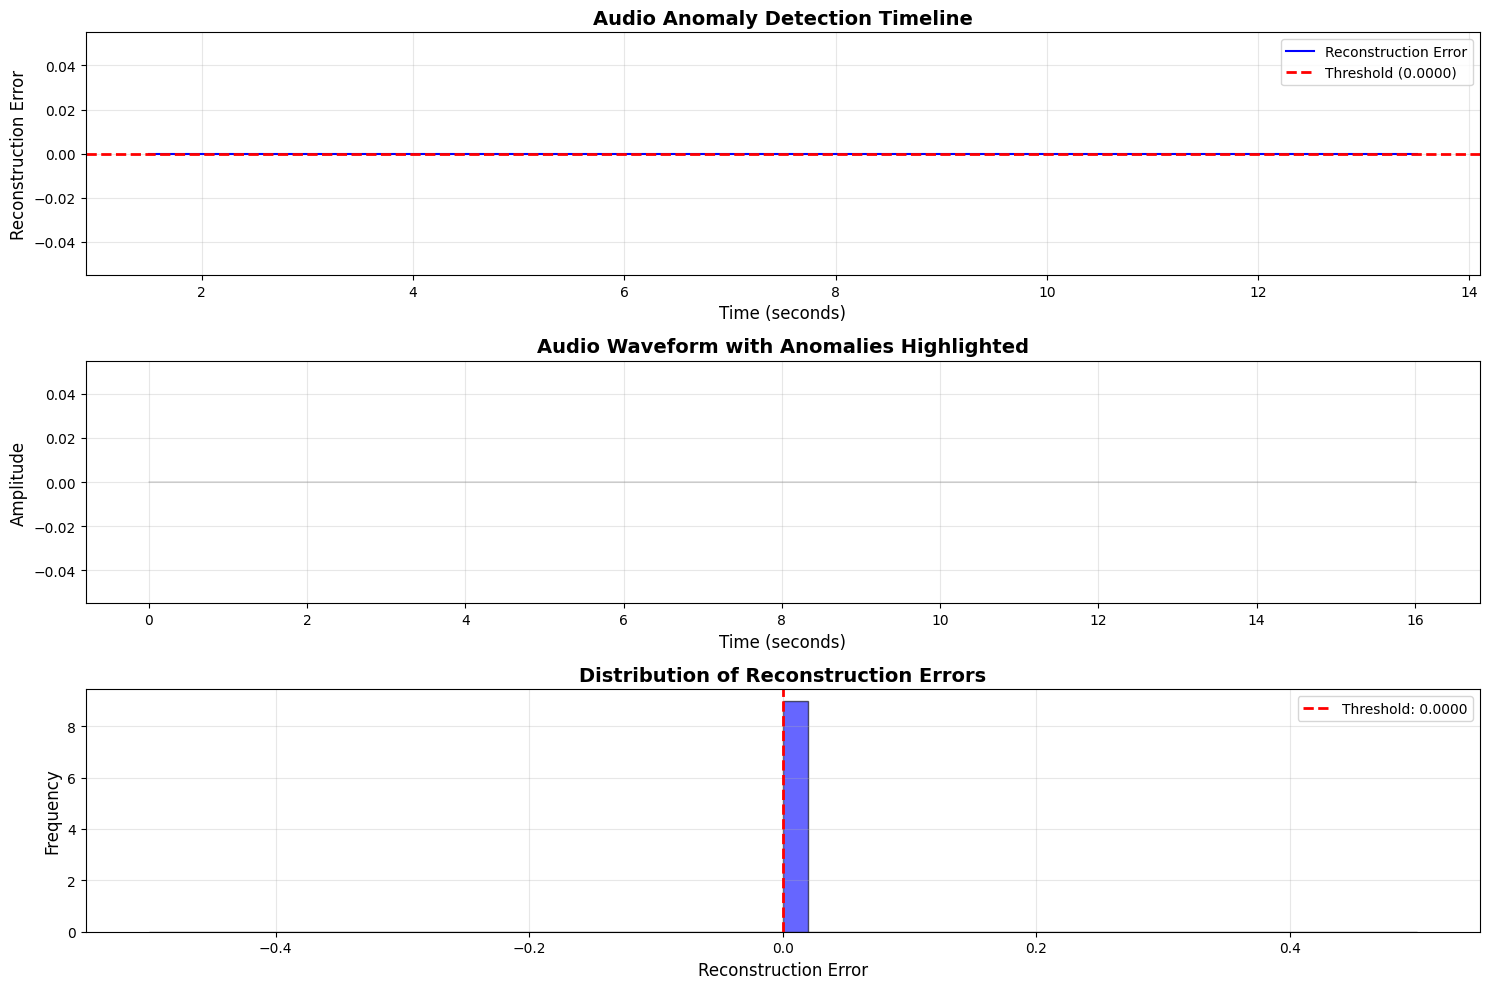

✅ Visualization saved to: /content/drive/MyDrive/SceneSolverG388/SpectrogramAnanlysis/results/anomaly_visualization.png


In [ ]:
# ============================================================================
# CELL 10: TEST ON ANOMALY VIDEO - FIXED
# ============================================================================

print("\n" + "="*60)
print("ANOMALY DETECTION INFERENCE")
print("="*60)

# Load best model with error handling
best_model_path = f"{config.MODELS_DIR}/best_model.pth"

if not os.path.exists(best_model_path):
    print("❌ Best model not found. This can happen if:")
    print("   1. Training produced NaN losses (all epochs)")
    print("   2. No validation was performed")
    print("\n⚠️  Using current model state instead...")

    # Save current model as fallback
    checkpoint = {
        'epoch': config.EPOCHS,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': history['train_loss'][-1] if history['train_loss'] else 0.0,
        'config': {
            'latent_dim': config.LATENT_DIM,
            'n_mels': config.N_MELS,
            'sample_rate': config.SAMPLE_RATE,
            'duration': config.DURATION
        }
    }
    torch.save(checkpoint, best_model_path)
    print(f"✅ Saved current model to: {best_model_path}")
else:
    # Load best model
    checkpoint = torch.load(best_model_path, map_location=config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"✅ Loaded best model from epoch {checkpoint['epoch']}")
    print(f"   Validation loss: {checkpoint['loss']:.6f}")

# IMPORTANT: User needs to upload their anomaly video
print("\n⚠️  UPLOAD YOUR ANOMALY VIDEO")
print("    1. Click the folder icon on the left (Files)")
print("    2. Upload your test video to /content/")
print("    3. Update ANOMALY_VIDEO_PATH below with the correct filename")
print()

# Example path - UPDATE THIS
ANOMALY_VIDEO_PATH = "/content/drive/MyDrive/SceneSolverG388/AnomalyDetection/normal/Normal_Videos_015_x264.mp4"  # ← CHANGE THIS TO YOUR VIDEO

# Check if file exists
if not os.path.exists(ANOMALY_VIDEO_PATH):
    print(f"❌ Video not found: {ANOMALY_VIDEO_PATH}")
    print("   Please upload your anomaly video and update the path above.")
    print("\n💡 TIP: You can also use Google Drive:")
    print("   ANOMALY_VIDEO_PATH = '/content/drive/MyDrive/your_video.mp4'")
else:
    # Extract audio from anomaly video
    anomaly_audio_path = "/content/anomaly_test_audio.wav"

    print(f"Extracting audio from: {ANOMALY_VIDEO_PATH}")
    if extract_audio_from_video(ANOMALY_VIDEO_PATH, anomaly_audio_path, sr=config.SAMPLE_RATE):
        print("✅ Audio extracted successfully")

        # Detect anomalies
        print("\nRunning anomaly detection...")
        anomalies, scores, timestamps, threshold = detect_anomaly_in_audio(
            anomaly_audio_path, model, config, threshold_percentile=95
        )

        # Print results
        print("\n" + "="*60)
        print("RESULTS")
        print("="*60)
        print(f"Total windows analyzed: {len(scores)}")
        print(f"Anomaly threshold (95th percentile): {threshold:.6f}")
        print(f"Anomalies detected: {len(anomalies)}")

        if len(anomalies) > 0:
            print("\n⚠️  ANOMALIES FOUND:")
            for i, anom in enumerate(anomalies, 1):
                print(f"  {i}. Time: {anom['start_time']:.2f}s - {anom['end_time']:.2f}s")
                print(f"     Score: {anom['score']:.6f} (threshold: {anom['threshold']:.6f})")
        else:
            print("\n✅ No anomalies detected (all audio sounds normal)")

        # Save results
        results = {
            'video_path': ANOMALY_VIDEO_PATH,
            'total_windows': len(scores),
            'threshold': float(threshold),
            'num_anomalies': len(anomalies),
            'anomalies': anomalies
        }

        results_path = f"{config.RESULTS_DIR}/anomaly_detection_results.json"
        with open(results_path, 'w') as f:
            json.dump(results, f, indent=2)

        print(f"\n💾 Results saved to: {results_path}")

    else:
        print("❌ Failed to extract audio from video")

# ============================================================================
# CELL 11: VISUALIZE ANOMALY DETECTION - FIXED
# ============================================================================

if os.path.exists(ANOMALY_VIDEO_PATH) and 'anomalies' in locals() and len(scores) > 0:
    print("\n" + "="*60)
    print("VISUALIZATION")
    print("="*60)

    # Plot anomaly scores over time
    fig, axes = plt.subplots(3, 1, figsize=(15, 10))

    # 1. Anomaly scores timeline
    ax = axes[0]
    time_points = [(t[0] + t[1]) / 2 for t in timestamps]
    ax.plot(time_points, scores, 'b-', linewidth=1.5, label='Reconstruction Error')
    ax.axhline(y=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold ({threshold:.4f})')

    # Highlight anomalies
    for anom in anomalies:
        ax.axvspan(anom['start_time'], anom['end_time'], alpha=0.3, color='red')

    ax.set_xlabel('Time (seconds)', fontsize=12)
    ax.set_ylabel('Reconstruction Error', fontsize=12)
    ax.set_title('Audio Anomaly Detection Timeline', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Waveform with anomaly markers
    ax = axes[1]
    try:
        y_full, sr_full = librosa.load(anomaly_audio_path, sr=config.SAMPLE_RATE)
        time_axis = np.linspace(0, len(y_full) / sr_full, len(y_full))
        ax.plot(time_axis, y_full, 'gray', linewidth=0.5, alpha=0.7)

        # Mark anomalies
        for anom in anomalies:
            ax.axvspan(anom['start_time'], anom['end_time'], alpha=0.4, color='red')

        ax.set_xlabel('Time (seconds)', fontsize=12)
        ax.set_ylabel('Amplitude', fontsize=12)
        ax.set_title('Audio Waveform with Anomalies Highlighted', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)
    except:
        ax.text(0.5, 0.5, 'Could not load waveform', ha='center', va='center', transform=ax.transAxes)

    # 3. Score distribution
    ax = axes[2]
    ax.hist(scores, bins=50, color='blue', alpha=0.6, edgecolor='black')
    ax.axvline(x=threshold, color='r', linestyle='--', linewidth=2, label=f'Threshold: {threshold:.4f}')
    ax.set_xlabel('Reconstruction Error', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('Distribution of Reconstruction Errors', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    # Save figure
    vis_path = f"{config.RESULTS_DIR}/anomaly_visualization.png"
    plt.savefig(vis_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"✅ Visualization saved to: {vis_path}")